# Execution Time: Scalar-Vector Product

In this notebook, we will compare the execution time of our implementation with NumPy's `numpy.dot` function. We will use the [`timeit`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit) function for performance measurements.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
import my_functions as mf

In [2]:
N = np.array([100, 300, 500, 700, 1000, 10000])

In [3]:
list_time_dumb = []
list_time_numpy = []
for Ni in N:
    scalar = 1
    vector = np.ones(Ni)
    # scalar_vec_real_dumb
    time = %timeit -o -n 100 -r 50 mf.scalar_vec_real(scalar, vector, check_input=False)
    list_time_dumb.append(time.average)
    # scalar_vec_real_numpy
    time = %timeit -o -n 100 -r 50 scalar*vector
    list_time_numpy.append(time.average)

19.1 μs ± 7.56 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
729 ns ± 23.4 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
32.7 μs ± 187 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
751 ns ± 13.7 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
56.1 μs ± 776 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
775 ns ± 22 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
81.1 μs ± 1.87 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
890 ns ± 182 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
127 μs ± 6.19 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
891 ns ± 156 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.2 ms ± 28.8 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.84 μs ± 219 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [4]:
list_time_dumb = np.array(list_time_dumb)
list_time_numpy = np.array(list_time_numpy)

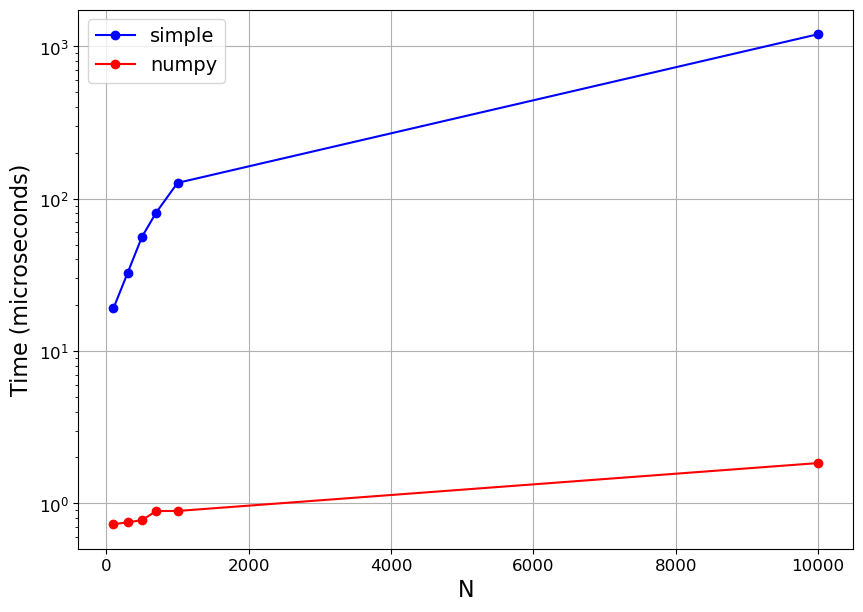

In [5]:
plt.figure(figsize=(10,7))
plt.plot(N, list_time_dumb*1e6, 'bo-', label = 'simple')
plt.plot(N, list_time_numpy*1e6, 'ro-', label = 'numpy')
plt.legend(loc = 'best', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('N', fontsize = 16)
plt.ylabel('Time (microseconds)', fontsize = 16)
plt.yscale('log')
plt.grid()
plt.show()